In [1]:
#Version Numbers Used to Generate this Pset:
#seaborn=0.11.2
#scipy==1.8.0
#numpy==1.22.2
#matplotlib==3.5.1

import scipy as sp
from pylab import *
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator,FormatStrFormatter,MaxNLocator
import pandas as pd
import seaborn as sns
import collections
from IPython.display import clear_output
import random
import openpyxl
import os 
sns.set_style("ticks")
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, explained_variance_score, r2_score
from sklearn.preprocessing import PolynomialFeatures
import pickle

DataTitle="Data_dynamics"

np.random.seed(1)
if not os.path.exists(DataTitle):

   # Create a new directory because it does not exist
   os.makedirs(DataTitle)
   print("The new directory is created!")

mm = 0.1/2.54
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin/latex'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['xtick.minor.width'] = 0.4
mpl.rcParams['xtick.major.width'] = 0.5
mpl.rcParams['ytick.minor.width'] = 0.4
mpl.rcParams['ytick.major.width'] = 0.5

plt.rcParams['text.usetex'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

sns.color_palette("tab10")

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

In [2]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

my_cmap = ListedColormap(['#00429d', '#4771b2', '#73a2c6', '#a5d5d8', '#ffffe0', '#ffbcaf', '#f4777f', '#cf3759', '#93003a'], name="my_cmap")
my_cmap_r = my_cmap.reversed()
mpl.colormaps.register(cmap=my_cmap)
mpl.colormaps.register(cmap=my_cmap_r)

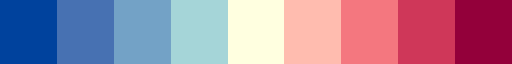

In [3]:
my_cmap

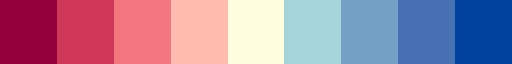

In [4]:
my_cmap_r

In [5]:
def getIDX(data, IDX):
    O = np.flatnonzero([x == IDX for x in data['SampleIDX']])
    return np.array(O)

def getAbundance(Processed_sequences,IDX):
    SampleIdx= np.flatnonzero([x == IDX for x in Processed_sequences['SampleIDX']])
    if not any(SampleIdx):
        return
    else:
        O=Processed_sequences.iloc[SampleIdx].values.tolist()[0][1:]
        return O

def getAbundance_fromList(Processed_sequences,IDX_list):
    IDX_list_=np.squeeze([np.where(Processed_sequences['SampleIDX']==x) for x in IDX_list])
    return (np.array(Processed_sequences.iloc[IDX_list_].values)[:,1:]).astype(float)

def Community_PermutateList_simulation(I,S):
    global Metadata,exception_list
    sample_num=100
    O=(3*(I-1)+(S-1))*100+np.arange(0,100)
    return O

def CommunityPermutate(Timepoint, CommunityOrigin, Medium, CoalescenceType):
    global Metadata
    idx = np.where((Metadata['Timepoint'] == Timepoint) &
                   (Metadata['CommunityOrigin'] == CommunityOrigin) &
                   (Metadata['Medium'] == Medium) &
                   (Metadata['CoalescenceType'] == CoalescenceType))[0]
    O = np.concatenate(Metadata['SampleIDX'][idx])
    return O

def CommunityPermutate_withSpeciesPoolsize(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num):
    global Metadata,exception_list
    idx = (Metadata['Timepoint'] == Timepoint) & \
          (Metadata['CommunityOrigin'] == CommunityOrigin) & \
          (Metadata['Medium'] == Medium) & \
          (Metadata['CoalescenceType'] == CoalescenceType)

    communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
    if CoalescenceType == 'S':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 9)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
    elif CoalescenceType == 'C':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 14)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 41) & (communityIDX <= 47))

    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def Community_PermutateList(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num=0, Replicate=-1):
    global Metadata,exception_list
    
    if Replicate==-1:
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType)
    elif Replicate == 1 or Replicate == 2 : 
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType) & \
              (Metadata['Replicate'] == Replicate)
    else : 
        raise ValueError("Invalid input")

    
    if CommunityOrigin=='S':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        if CoalescenceType == 'S':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 9)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
            elif species_pool_num ==0:
                idx = idx
        elif CoalescenceType == 'C':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 14)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 41) & (communityIDX <= 47))
            elif species_pool_num ==0:
                idx = idx
    elif CommunityOrigin=='N':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        
    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def getCommunities(Communities_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Communities_data['SampleIDX']==x) for x in IDX_list])
    return (Communities_data.iloc[IDX_list_])

def getCoalescence(Coalescence_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])#IDX_list_
    return (Coalescence_data.iloc[IDX_list_])

Coalescence_data_synthetic_path ="../../Analyzed/processed_CoalescenceEvent_synthetic.xlsx"
Communities_data_synthetic_path ="../../Analyzed/processed_Communities_synthetic.xlsx"
Coalescence_data_natural_path ="../../Analyzed/processed_CoalescenceEvent_natural.xlsx"
Communities_data_natural_path ="../../Analyzed/processed_Communities_natural.xlsx"
Coalescence_recipe_path="../../Postprocessed/CoalescenceRecipe.xlsx"
Meta_data_path="../../Postprocessed/Metadata.xlsx"
Processed_sequences_synthetic_path="../../Postprocessed/processed_Sequences_synthetic.xlsx"
Processed_sequences_natural_path="../../Postprocessed/processed_Sequences_natural.xlsx"
Coalescence_data_sim_path="../../Analyzed/processed_CoalescenceEvent_simulation_uniform.xlsx"
#Communities_data_sim_path="Analyzed/processed_Communities_simulation_uniform.xlsx"

Coalescence_data=pd.concat([pd.read_excel(Coalescence_data_synthetic_path),pd.read_excel(Coalescence_data_natural_path)])
Communities_data=pd.concat([pd.read_excel(Communities_data_synthetic_path),pd.read_excel(Communities_data_natural_path)])
Coalescence_data_sim=pd.read_excel(Coalescence_data_sim_path)
#Communities_data_sim=pd.read_excel(Communities_data_sim_path)

Coalescence_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=0)
Coalescence_natural_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=1)
Metadata=pd.read_excel(Meta_data_path)
Processed_sequences_synthetic=pd.read_excel(Processed_sequences_synthetic_path)
Processed_sequences_natural=pd.read_excel(Processed_sequences_natural_path)

exception_list=['P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12']+['P8-91'] + ['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] + ['P5-47', 'P5-50'] + ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57']
#'P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12' : These cases are for no reads in coalescence result
# 'P8-91' : no file
#['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] : MN E7 is missing
# 'P6-67' : is too low reads( 500)
# 'P5-47', 'P5-50' : MN24 CC, too much unwanted ASVs(maybe due to wrong labeling)
# ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57'] : ASV not in sub 2> 0.3

I = [0.33, 0.66, 0.99]
species_pools = [6, 12, 24]
sample_num=100
Syn_Simulation_IDX = {
    "I1_S1": Community_PermutateList_simulation(1,1),
    "I1_S2": Community_PermutateList_simulation(1,2),
    "I1_S3": Community_PermutateList_simulation(1,3),
    "I2_S1": Community_PermutateList_simulation(2,1),
    "I2_S2": Community_PermutateList_simulation(2,2),
    "I2_S3": Community_PermutateList_simulation(2,3),
    "I3_S1": Community_PermutateList_simulation(3,1),
    "I3_S2": Community_PermutateList_simulation(3,2),
    "I3_S3": Community_PermutateList_simulation(3,3),
}
mediums_pools = ["LN", "MN", "HN"]
species_pools = [6, 12, 24]
Syn_Coal_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "C", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "C", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "C", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "C", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "C", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "C", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "C", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "C", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "C", 24)
}
Syn_Sub_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "S", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "S", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "S", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "S", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "S", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "S", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "S", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "S", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "S", 24)
}
Nat_Coal_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "C"),
    "MN": Community_PermutateList("F", "N", "M", "C"),
    "HN": Community_PermutateList("F", "N", "H", "C")
}
Nat_Sub_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "S"),
    "MN": Community_PermutateList("F", "N", "M", "S"),
    "HN": Community_PermutateList("F", "N", "H", "S")
}




In [6]:
from InitializeSpeciesPool import *
from LV import *
from VariousMetrics import *

########################################################
########################################################
# Fig 3-1
########################################################
########################################################

##~~~~~~~~~~~~~~ This figure is cartoon ~~~~~~~~~~~~~~##

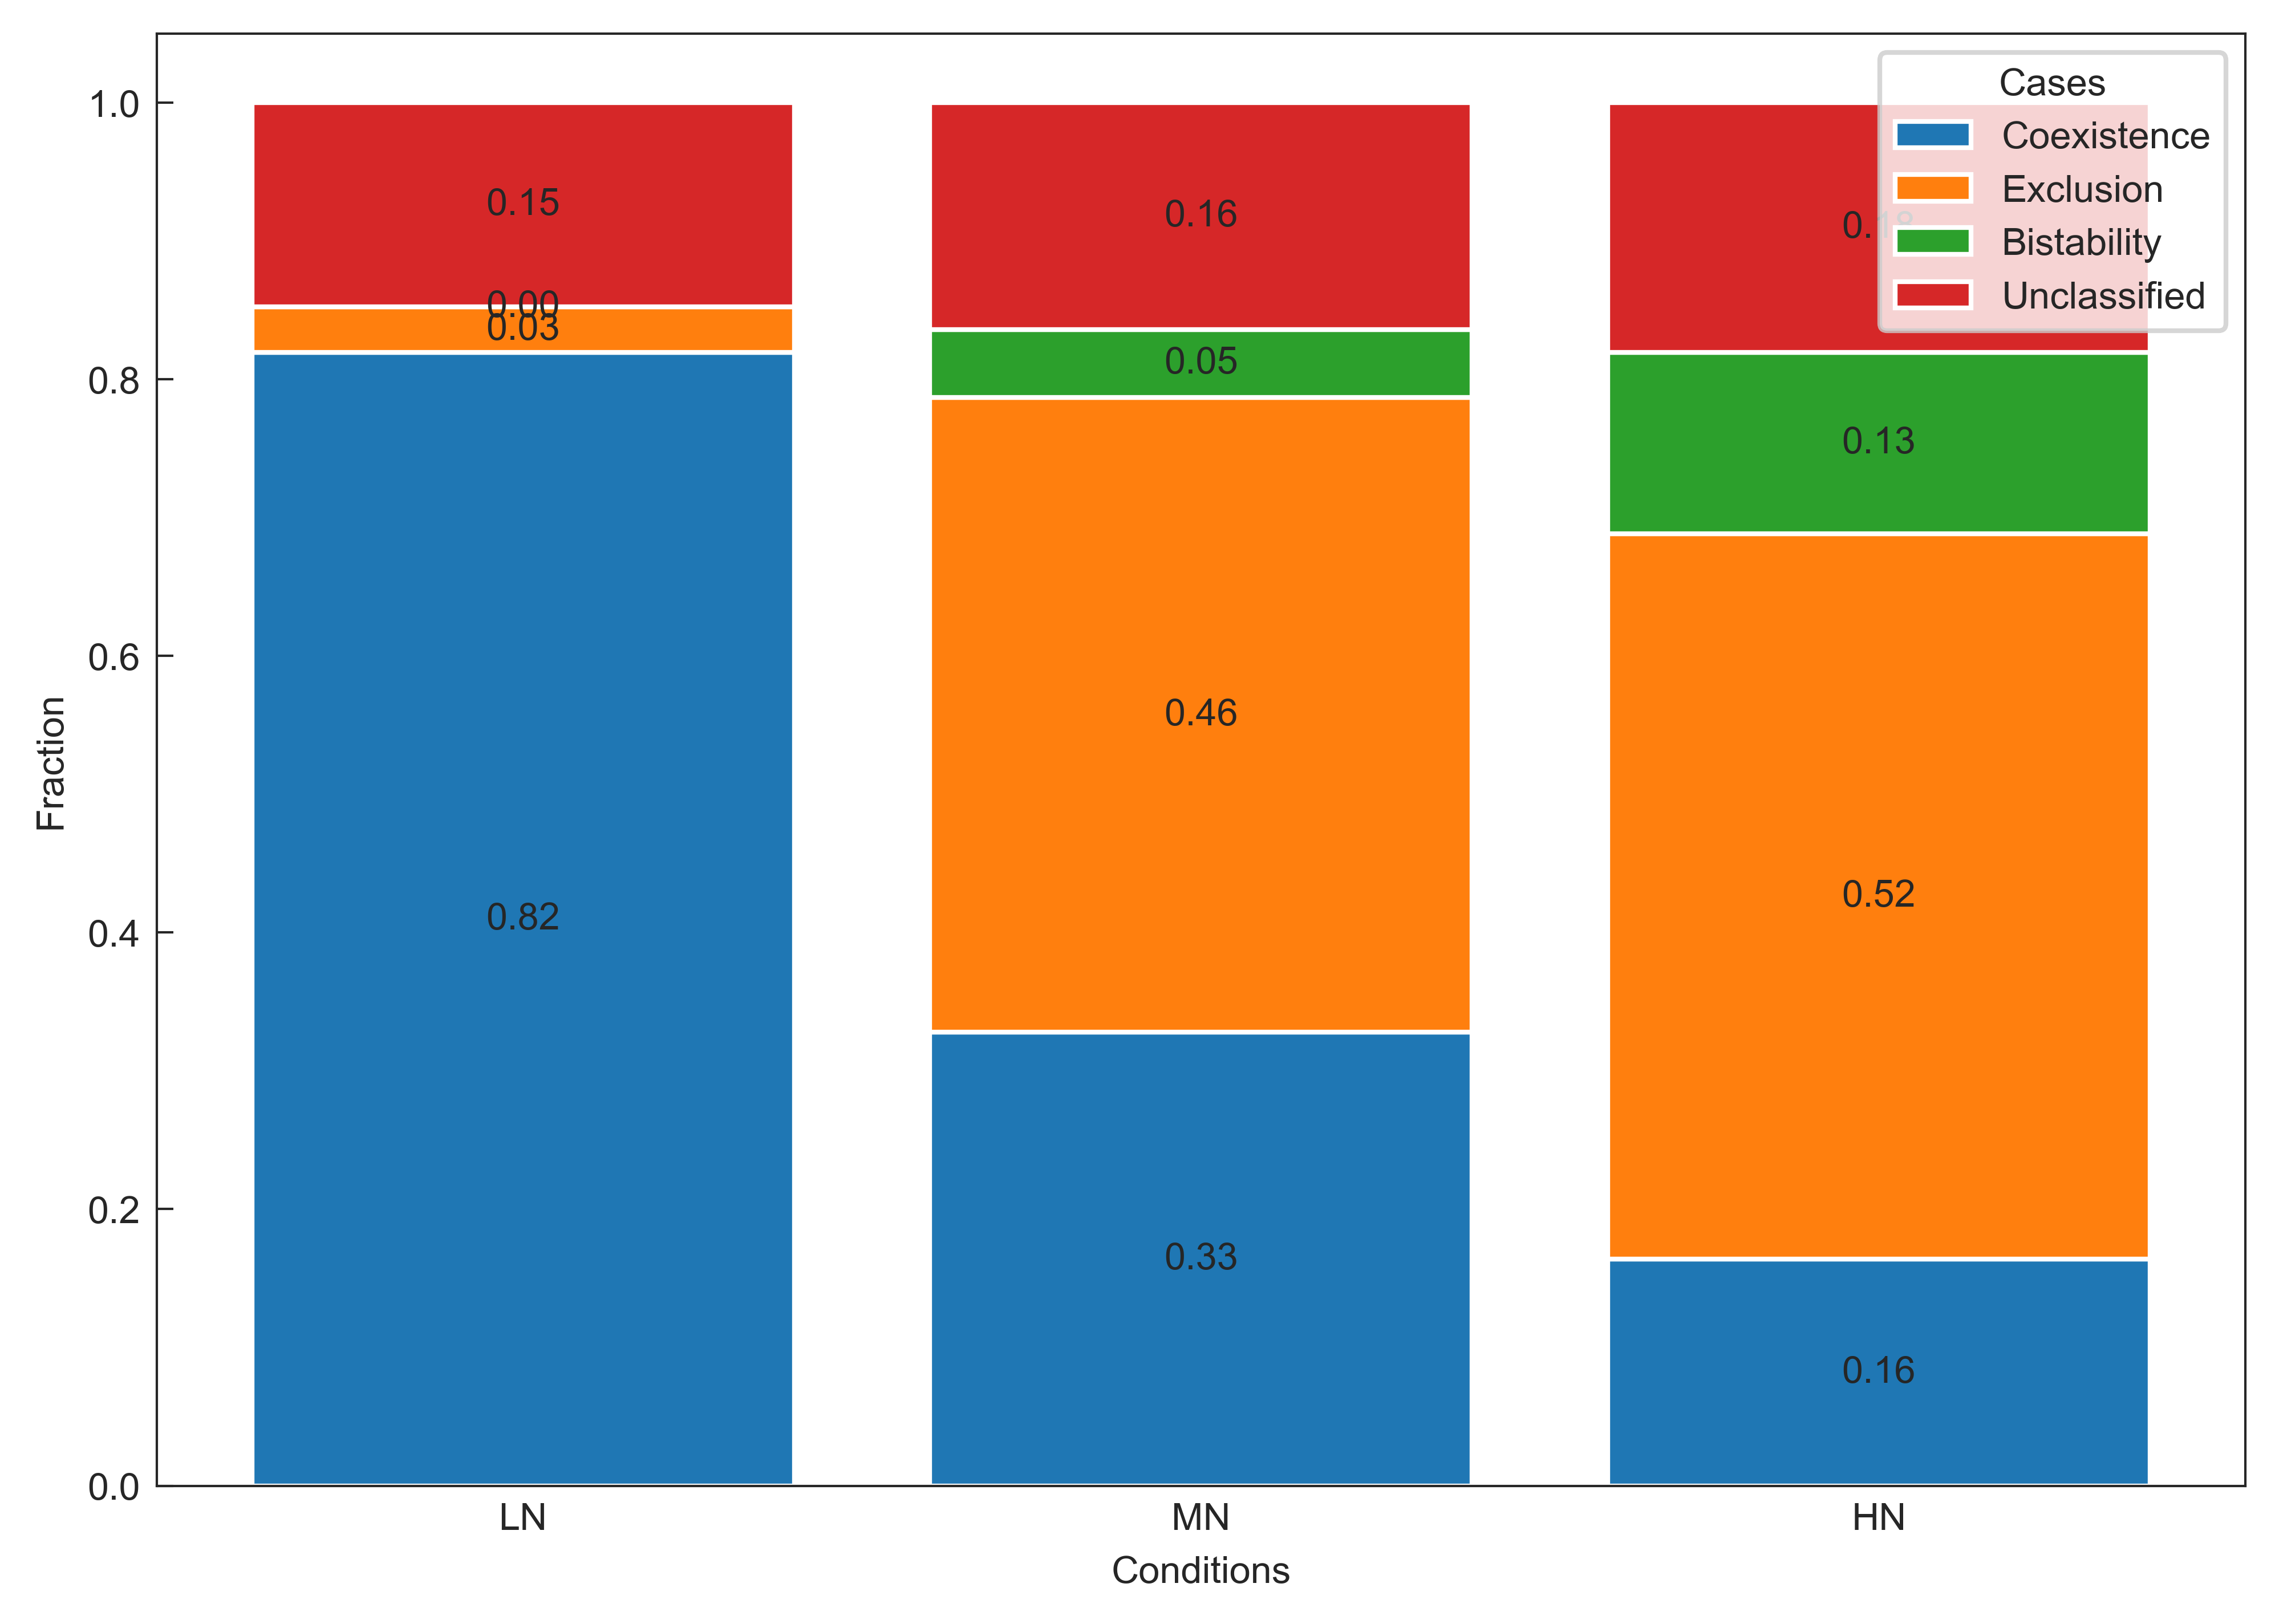

In [7]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, figsize=(200*mm,140*mm))

# Define the lists
LN_case_list = ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'U', 'U', 'C', 'C', 'C', 'C',
                'C', 'U', 'C', 'C', 'U', 'E', 'C', 'C', 'C', 'C', 'C', 'C', 'C',
                'C', 'C', 'C', 'C', 'C', 'C', 'C', 'U', 'C', 'C', 'C', 'C', 'C',
                'C', 'C', 'C', 'C', 'C', 'U', 'C', 'C', 'C', 'C', 'U', 'U', 'C',
                'C', 'U', 'C', 'C', 'C', 'C', 'C', 'E', 'C']

MN_case_list = ['U', 'E', 'U', 'E', 'E', 'E', 'U', 'U', 'C', 'E', 'E', 'U', 'C',
                'E', 'E', 'E', 'B', 'C', 'E', 'C', 'E', 'E', 'E', 'E', 'E', 'E',
                'E', 'E', 'C', 'C', 'C', 'E', 'B', 'U', 'E', 'C', 'U', 'E', 'C',
                'C', 'E', 'C', 'E', 'C', 'C', 'E', 'C', 'E', 'C', 'C', 'E', 'C',
                'C', 'U', 'U', 'C', 'C', 'B', 'E', 'U', 'E']

HN_case_list = ['E', 'E', 'E', 'E', 'E', 'B', 'E', 'U', 'U', 'E', 'E', 'E', 'U',
                'B', 'E', 'E', 'B', 'C', 'B', 'C', 'E', 'E', 'E', 'E', 'E', 'B',
                'E', 'E', 'U', 'U', 'E', 'E', 'E', 'C', 'E', 'C', 'U', 'U', 'U',
                'C', 'E', 'B', 'B', 'U', 'C', 'E', 'C', 'E', 'C', 'C', 'E', 'E',
                'U', 'U', 'E', 'E', 'C', 'B', 'E', 'E', 'E']

# Count the occurrences of each case in each condition
LN_counts = {'C': LN_case_list.count('C'), 'U': LN_case_list.count('U'), 'E': LN_case_list.count('E'), 'B': LN_case_list.count('B')}
MN_counts = {'C': MN_case_list.count('C'), 'U': MN_case_list.count('U'), 'E': MN_case_list.count('E'), 'B': MN_case_list.count('B')}
HN_counts = {'C': HN_case_list.count('C'), 'U': HN_case_list.count('U'), 'E': HN_case_list.count('E'), 'B': HN_case_list.count('B')}

# Calculate the total counts for each condition
LN_total = len(LN_case_list)
MN_total = len(MN_case_list)
HN_total = len(HN_case_list)

# Calculate the fractions
LN_fractions = {key: LN_counts[key] / LN_total for key in LN_counts}
MN_fractions = {key: MN_counts[key] / MN_total for key in MN_counts}
HN_fractions = {key: HN_counts[key] / HN_total for key in HN_counts}

# Create a list of categories with the desired order
categories = ['LN', 'MN', 'HN']
colors  = [(0.85, 0.7, 0.7), (0.7,  0.7, 0.85), (0.7, 0.85, 0.7), (0.5, 0.5, 0.5)]

# Create the stacked bar plot with the desired category order
bars_c = plt.bar(categories, [LN_fractions['C'], MN_fractions['C'], HN_fractions['C']], label='C')
bars_e = plt.bar(categories, [LN_fractions['E'], MN_fractions['E'], HN_fractions['E']], label='E', bottom=[LN_fractions['C'], MN_fractions['C'], HN_fractions['C']])
bars_b = plt.bar(categories, [LN_fractions['B'], MN_fractions['B'], HN_fractions['B']], label='B', bottom=[LN_fractions['C'] + LN_fractions['E'], MN_fractions['C'] + MN_fractions['E'], HN_fractions['C'] + HN_fractions['E']])
bars_u = plt.bar(categories, [LN_fractions['U'], MN_fractions['U'], HN_fractions['U']], label='U', bottom=[LN_fractions['C'] + LN_fractions['E'] + LN_fractions['B'], MN_fractions['C'] + MN_fractions['E'] + MN_fractions['B'], HN_fractions['C'] + HN_fractions['E'] + HN_fractions['B']])

# Add labels and legend
plt.xlabel('Conditions')
plt.ylabel('Fraction')
plt.legend(['Coexistence', 'Exclusion', 'Bistability', 'Unclassified'],title='Cases')


# Add text labels for the fraction values on each bar
for bar_c, bar_e, bar_b, bar_u in zip(bars_c, bars_e, bars_b, bars_u):
    plt.text(bar_c.get_x() + bar_c.get_width() / 2, bar_c.get_height() / 2, f'{bar_c.get_height():.2f}', ha='center', va='center')
    plt.text(bar_e.get_x() + bar_e.get_width() / 2, bar_c.get_height() + bar_e.get_height() / 2, f'{bar_e.get_height():.2f}', ha='center', va='center')
    plt.text(bar_b.get_x() + bar_b.get_width() / 2, bar_c.get_height() + bar_e.get_height() + bar_b.get_height() / 2, f'{bar_b.get_height():.2f}', ha='center', va='center')
    plt.text(bar_u.get_x() + bar_u.get_width() / 2, bar_c.get_height() + bar_e.get_height() + bar_b.get_height() + bar_u.get_height() / 2 , f'{bar_u.get_height():.2f}', ha='center', va='center')

# Show the plot
plt.show()

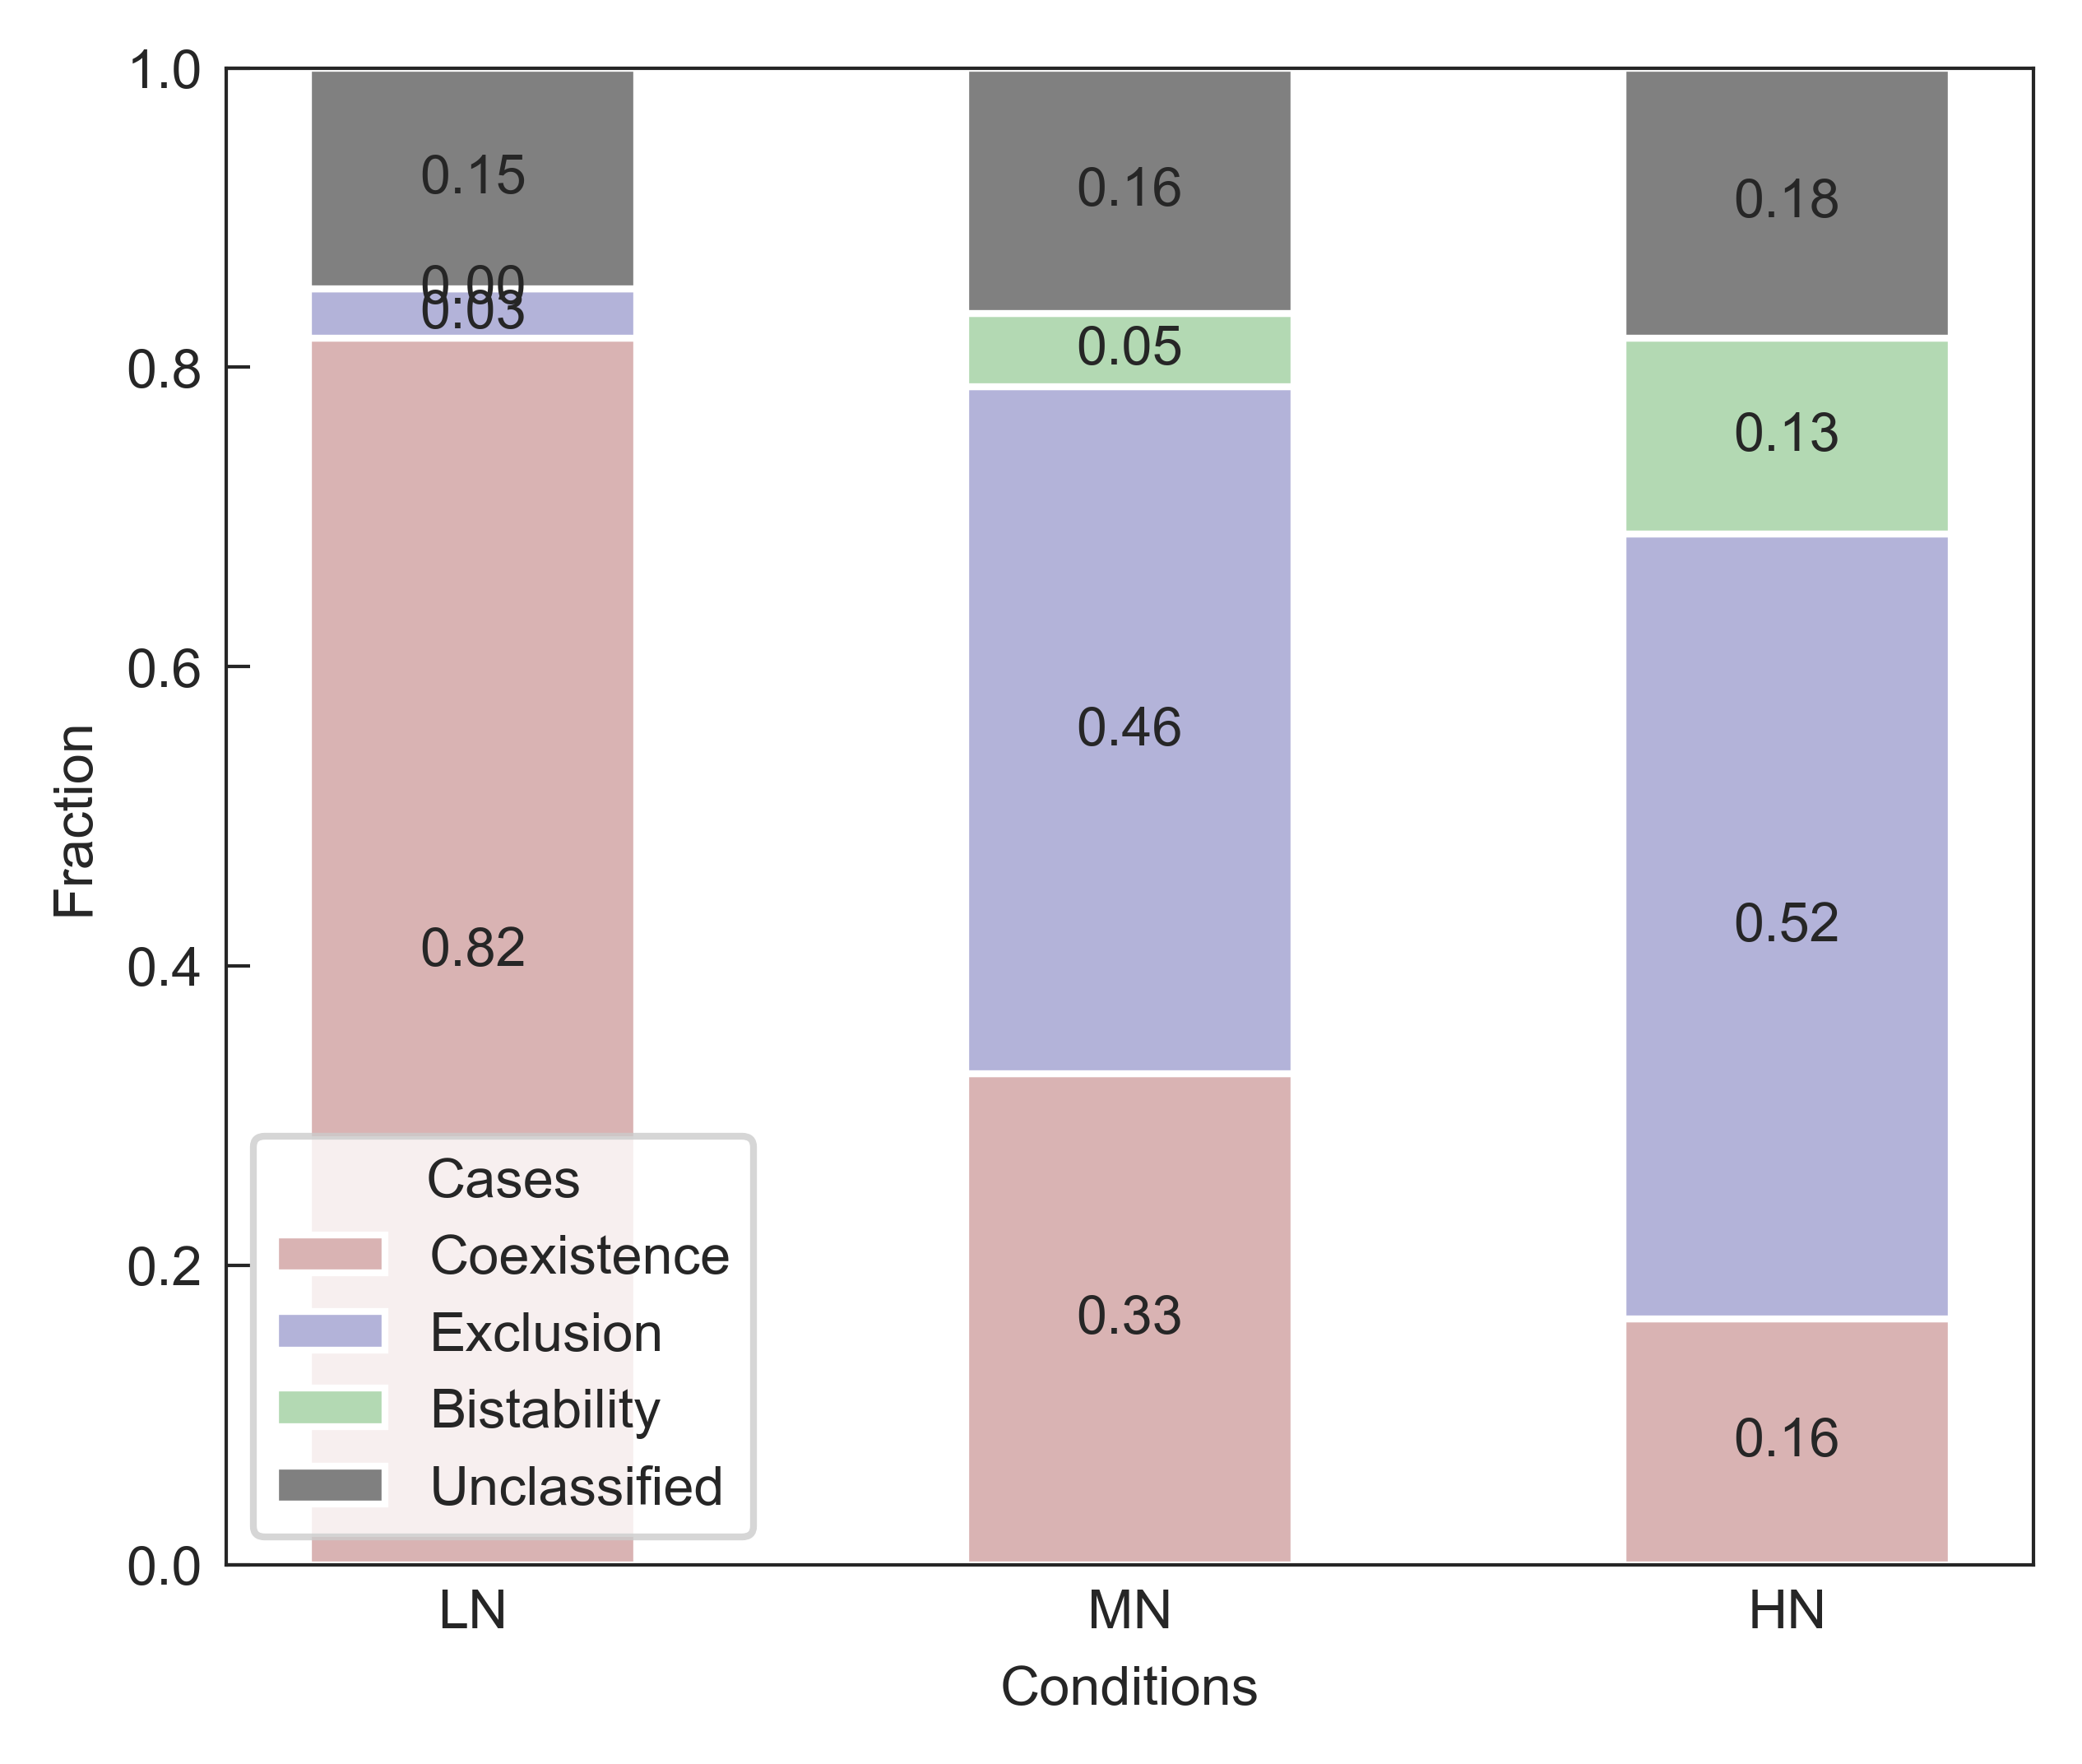

In [8]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, figsize=(120*mm,100*mm))

# Define the lists
LN_case_list = ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'U', 'U', 'C', 'C', 'C', 'C',
                'C', 'U', 'C', 'C', 'U', 'E', 'C', 'C', 'C', 'C', 'C', 'C', 'C',
                'C', 'C', 'C', 'C', 'C', 'C', 'C', 'U', 'C', 'C', 'C', 'C', 'C',
                'C', 'C', 'C', 'C', 'C', 'U', 'C', 'C', 'C', 'C', 'U', 'U', 'C',
                'C', 'U', 'C', 'C', 'C', 'C', 'C', 'E', 'C']

MN_case_list = ['U', 'E', 'U', 'E', 'E', 'E', 'U', 'U', 'C', 'E', 'E', 'U', 'C',
                'E', 'E', 'E', 'B', 'C', 'E', 'C', 'E', 'E', 'E', 'E', 'E', 'E',
                'E', 'E', 'C', 'C', 'C', 'E', 'B', 'U', 'E', 'C', 'U', 'E', 'C',
                'C', 'E', 'C', 'E', 'C', 'C', 'E', 'C', 'E', 'C', 'C', 'E', 'C',
                'C', 'U', 'U', 'C', 'C', 'B', 'E', 'U', 'E']

HN_case_list = ['E', 'E', 'E', 'E', 'E', 'B', 'E', 'U', 'U', 'E', 'E', 'E', 'U',
                'B', 'E', 'E', 'B', 'C', 'B', 'C', 'E', 'E', 'E', 'E', 'E', 'B',
                'E', 'E', 'U', 'U', 'E', 'E', 'E', 'C', 'E', 'C', 'U', 'U', 'U',
                'C', 'E', 'B', 'B', 'U', 'C', 'E', 'C', 'E', 'C', 'C', 'E', 'E',
                'U', 'U', 'E', 'E', 'C', 'B', 'E', 'E', 'E']


# Count the occurrences of each case in each condition
LN_counts = {'C': LN_case_list.count('C'), 'U': LN_case_list.count('U'), 'E': LN_case_list.count('E'), 'B': LN_case_list.count('B')}
MN_counts = {'C': MN_case_list.count('C'), 'U': MN_case_list.count('U'), 'E': MN_case_list.count('E'), 'B': MN_case_list.count('B')}
HN_counts = {'C': HN_case_list.count('C'), 'U': HN_case_list.count('U'), 'E': HN_case_list.count('E'), 'B': HN_case_list.count('B')}

# Calculate the total counts for each condition
LN_total = len(LN_case_list)
MN_total = len(MN_case_list)
HN_total = len(HN_case_list)

# Calculate the fractions
LN_fractions = {key: LN_counts[key] / LN_total for key in LN_counts}
MN_fractions = {key: MN_counts[key] / MN_total for key in MN_counts}
HN_fractions = {key: HN_counts[key] / HN_total for key in HN_counts}

# Create a list of categories with the desired order
categories = ['LN', 'MN', 'HN']
colors  = [(0.85, 0.7, 0.7), (0.7,  0.7, 0.85), (0.7, 0.85, 0.7), (0.5, 0.5, 0.5)]

# Create the stacked bar plot with the desired category order
bars_c = plt.bar(categories, [LN_fractions['C'], MN_fractions['C'], HN_fractions['C']], width=0.5, color=colors[0], label='C')
bars_e = plt.bar(categories, [LN_fractions['E'], MN_fractions['E'], HN_fractions['E']], width=0.5, color=colors[1], label='E', bottom=[LN_fractions['C'], MN_fractions['C'], HN_fractions['C']])
bars_b = plt.bar(categories, [LN_fractions['B'], MN_fractions['B'], HN_fractions['B']], width=0.5, color=colors[2], label='B', bottom=[LN_fractions['C'] + LN_fractions['E'], MN_fractions['C'] + MN_fractions['E'], HN_fractions['C'] + HN_fractions['E']])
bars_u = plt.bar(categories, [LN_fractions['U'], MN_fractions['U'], HN_fractions['U']], width=0.5, color=colors[3], label='U', bottom=[LN_fractions['C'] + LN_fractions['E'] + LN_fractions['B'], MN_fractions['C'] + MN_fractions['E'] + MN_fractions['B'], HN_fractions['C'] + HN_fractions['E'] + HN_fractions['B']])

# Add labels and legend
plt.ylim([0,1])
plt.xlabel('Conditions')
plt.ylabel('Fraction')
plt.legend(['Coexistence', 'Exclusion', 'Bistability', 'Unclassified'],title='Cases')


# Add text labels for the fraction values on each bar
for bar_c, bar_e, bar_b, bar_u in zip(bars_c, bars_e, bars_b, bars_u):
    plt.text(bar_c.get_x() + bar_c.get_width() / 2, bar_c.get_height() / 2, f'{bar_c.get_height():.2f}', ha='center', va='center')
    plt.text(bar_e.get_x() + bar_e.get_width() / 2, bar_c.get_height() + bar_e.get_height() / 2, f'{bar_e.get_height():.2f}', ha='center', va='center')
    plt.text(bar_b.get_x() + bar_b.get_width() / 2, bar_c.get_height() + bar_e.get_height() + bar_b.get_height() / 2, f'{bar_b.get_height():.2f}', ha='center', va='center')
    plt.text(bar_u.get_x() + bar_u.get_width() / 2, bar_c.get_height() + bar_e.get_height() + bar_b.get_height() + bar_u.get_height() / 2 , f'{bar_u.get_height():.2f}', ha='center', va='center')

# Show the plot
fig.savefig('Figure/Fig_3-2_PairwiseInteraction_Boxplot.svg', bbox_inches='tight')

plt.show()

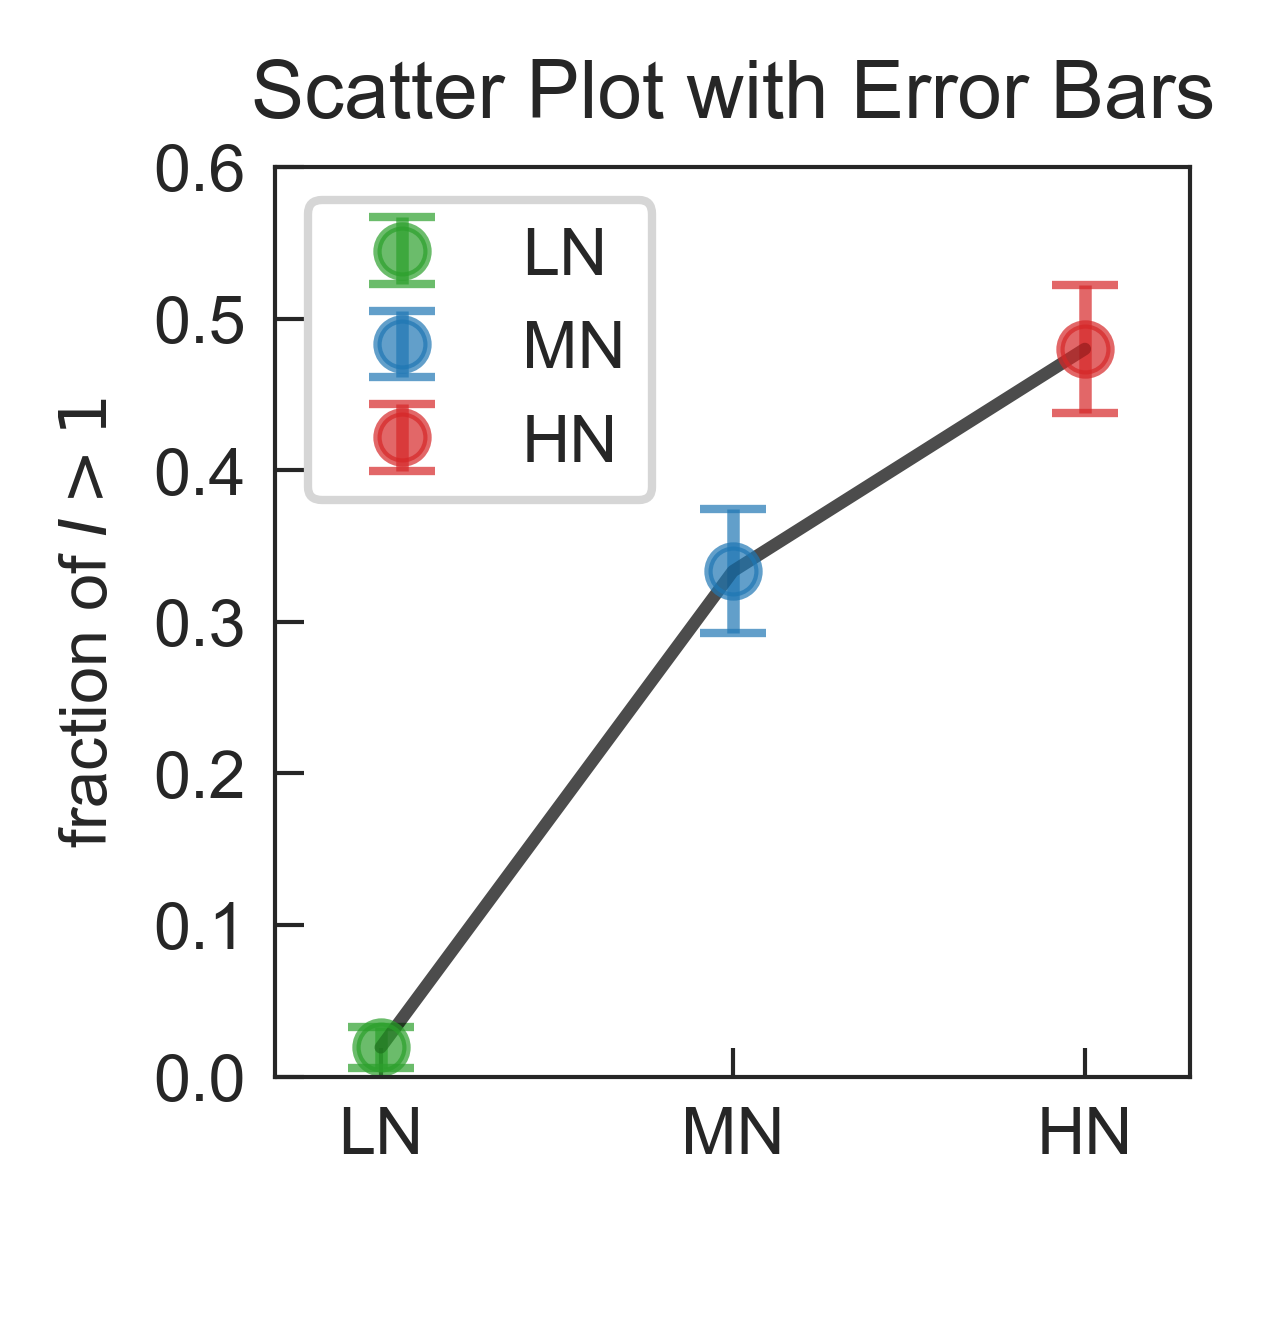

In [9]:
import matplotlib.pyplot as plt


# Define the lists
def convert_to_exc_ratio(case_list):
    # Convert the cases to their respective numbers (excluding 'U')
    num_list = [0 if case == 'C' else 0.5 if case == 'E' else 1 if case == 'B' else None for case in case_list]
    
    # Remove None values (which correspond to 'U' cases)
    num_list = [num for num in num_list if num is not None]
    
    # Return the count of each number
    return num_list

# Get the counts for each condition
LN_I_mean = np.mean(convert_to_exc_ratio(LN_case_list))
LN_I_mean_var = np.var(convert_to_exc_ratio(LN_case_list))/len(convert_to_exc_ratio(LN_case_list))

MN_I_mean = np.mean(convert_to_exc_ratio(MN_case_list))
MN_I_mean_var = np.var(convert_to_exc_ratio(MN_case_list)) / len(convert_to_exc_ratio(MN_case_list))

HN_I_mean = np.mean(convert_to_exc_ratio(HN_case_list))
HN_I_mean_var = np.var(convert_to_exc_ratio(HN_case_list)) / len(convert_to_exc_ratio(HN_case_list))



means = [LN_I_mean, MN_I_mean, HN_I_mean]
mean_vars = [LN_I_mean_var, MN_I_mean_var, HN_I_mean_var]

# Create a list of x positions for the groups
groups = ['LN', 'MN', 'HN']
x_pos = range(len(groups))

# Set up the figure
fig, axs = plt.subplots(1, figsize=(50*mm,50*mm))

# Plot scatter plot with error bars for the means
colors=([sns.color_palette("tab10")[2], sns.color_palette("tab10")[0], sns.color_palette("tab10")[3]])
for i, c in enumerate(colors):
    plt.errorbar(x_pos[i], means[i], yerr=np.sqrt(mean_vars)[i], fmt='o', color=c,capsize=4, label=groups[i], alpha=0.7)
plt.plot(x_pos, means,color='black', alpha=0.7)
plt.xlim(-0.3,2.3)
# Add labels and title
plt.xticks(x_pos, groups)
plt.xlabel(' ')
plt.ylabel('fraction of $I >1$')
plt.title('Scatter Plot with Error Bars')

# Add legend
plt.legend()

# Display the plot
# Add labels and legend
plt.ylim([0,0.6])

# Show the plot
fig.savefig('Figure/Fig_3-3_PairwiseInteraction_Errorbarplot.svg', bbox_inches='tight')

plt.show()

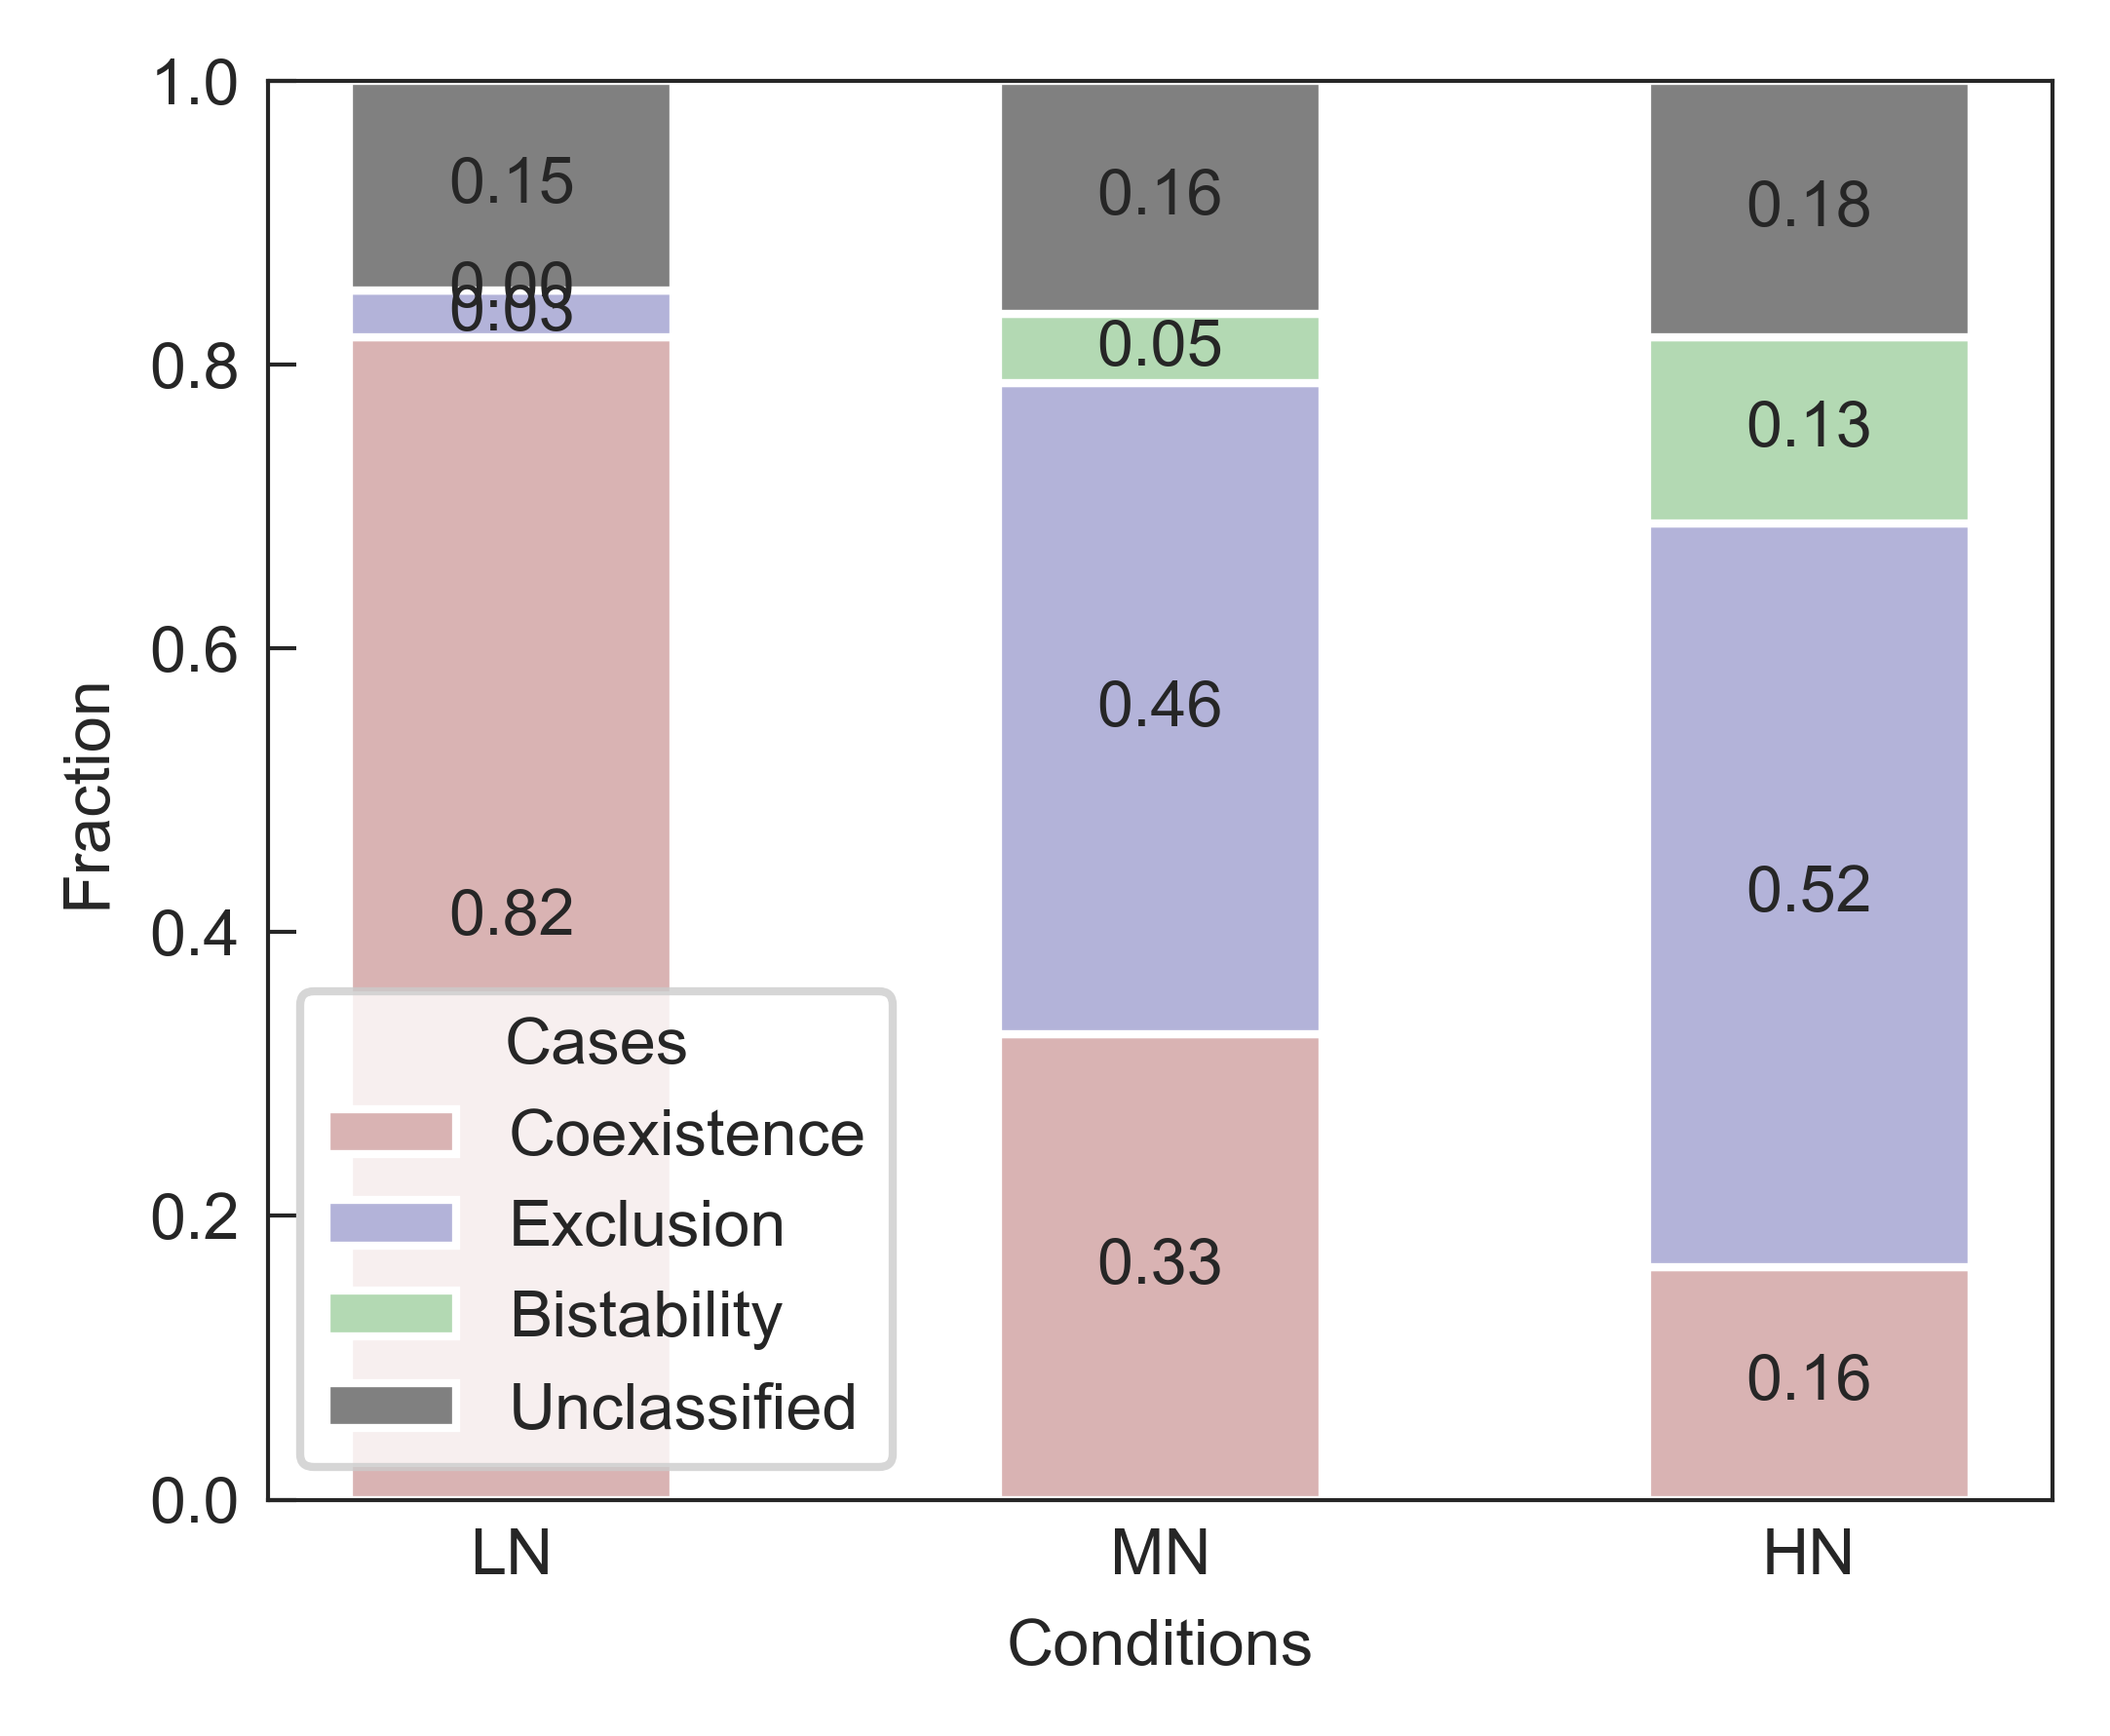

In [10]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, figsize=(100*mm,80*mm))

# Define the lists
LN_case_list = ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'U', 'U', 'C', 'C', 'C', 'C',
                'C', 'U', 'C', 'C', 'U', 'E', 'C', 'C', 'C', 'C', 'C', 'C', 'C',
                'C', 'C', 'C', 'C', 'C', 'C', 'C', 'U', 'C', 'C', 'C', 'C', 'C',
                'C', 'C', 'C', 'C', 'C', 'U', 'C', 'C', 'C', 'C', 'U', 'U', 'C',
                'C', 'U', 'C', 'C', 'C', 'C', 'C', 'E', 'C']

MN_case_list = ['U', 'E', 'U', 'E', 'E', 'E', 'U', 'U', 'C', 'E', 'E', 'U', 'C',
                'E', 'E', 'E', 'B', 'C', 'E', 'C', 'E', 'E', 'E', 'E', 'E', 'E',
                'E', 'E', 'C', 'C', 'C', 'E', 'B', 'U', 'E', 'C', 'U', 'E', 'C',
                'C', 'E', 'C', 'E', 'C', 'C', 'E', 'C', 'E', 'C', 'C', 'E', 'C',
                'C', 'U', 'U', 'C', 'C', 'B', 'E', 'U', 'E']

HN_case_list = ['E', 'E', 'E', 'E', 'E', 'B', 'E', 'U', 'U', 'E', 'E', 'E', 'U',
                'B', 'E', 'E', 'B', 'C', 'B', 'C', 'E', 'E', 'E', 'E', 'E', 'B',
                'E', 'E', 'U', 'U', 'E', 'E', 'E', 'C', 'E', 'C', 'U', 'U', 'U',
                'C', 'E', 'B', 'B', 'U', 'C', 'E', 'C', 'E', 'C', 'C', 'E', 'E',
                'U', 'U', 'E', 'E', 'C', 'B', 'E', 'E', 'E']


# Count the occurrences of each case in each condition
LN_counts = {'C': LN_case_list.count('C'), 'U': LN_case_list.count('U'), 'E': LN_case_list.count('E'), 'B': LN_case_list.count('B')}
MN_counts = {'C': MN_case_list.count('C'), 'U': MN_case_list.count('U'), 'E': MN_case_list.count('E'), 'B': MN_case_list.count('B')}
HN_counts = {'C': HN_case_list.count('C'), 'U': HN_case_list.count('U'), 'E': HN_case_list.count('E'), 'B': HN_case_list.count('B')}

# Calculate the total counts for each condition
LN_total = len(LN_case_list)
MN_total = len(MN_case_list)
HN_total = len(HN_case_list)

# Calculate the fractions
LN_fractions = {key: LN_counts[key] / LN_total for key in LN_counts}
MN_fractions = {key: MN_counts[key] / MN_total for key in MN_counts}
HN_fractions = {key: HN_counts[key] / HN_total for key in HN_counts}

# Create a list of categories with the desired order
categories = ['LN', 'MN', 'HN']
colors  = [(0.85, 0.7, 0.7), (0.7,  0.7, 0.85), (0.7, 0.85, 0.7), (0.5, 0.5, 0.5)]

# Create the stacked bar plot with the desired category order
bars_c = plt.bar(categories, [LN_fractions['C'], MN_fractions['C'], HN_fractions['C']], width=0.5, color=colors[0], label='C')
bars_e = plt.bar(categories, [LN_fractions['E'], MN_fractions['E'], HN_fractions['E']], width=0.5, color=colors[1], label='E', bottom=[LN_fractions['C'], MN_fractions['C'], HN_fractions['C']])
bars_b = plt.bar(categories, [LN_fractions['B'], MN_fractions['B'], HN_fractions['B']], width=0.5, color=colors[2], label='B', bottom=[LN_fractions['C'] + LN_fractions['E'], MN_fractions['C'] + MN_fractions['E'], HN_fractions['C'] + HN_fractions['E']])
bars_u = plt.bar(categories, [LN_fractions['U'], MN_fractions['U'], HN_fractions['U']], width=0.5, color=colors[3], label='U', bottom=[LN_fractions['C'] + LN_fractions['E'] + LN_fractions['B'], MN_fractions['C'] + MN_fractions['E'] + MN_fractions['B'], HN_fractions['C'] + HN_fractions['E'] + HN_fractions['B']])

# Add labels and legend
plt.ylim([0,1])
plt.xlabel('Conditions')
plt.ylabel('Fraction')
plt.legend(['Coexistence', 'Exclusion', 'Bistability', 'Unclassified'],title='Cases')


# Add text labels for the fraction values on each bar
for bar_c, bar_e, bar_b, bar_u in zip(bars_c, bars_e, bars_b, bars_u):
    plt.text(bar_c.get_x() + bar_c.get_width() / 2, bar_c.get_height() / 2, f'{bar_c.get_height():.2f}', ha='center', va='center')
    plt.text(bar_e.get_x() + bar_e.get_width() / 2, bar_c.get_height() + bar_e.get_height() / 2, f'{bar_e.get_height():.2f}', ha='center', va='center')
    plt.text(bar_b.get_x() + bar_b.get_width() / 2, bar_c.get_height() + bar_e.get_height() + bar_b.get_height() / 2, f'{bar_b.get_height():.2f}', ha='center', va='center')
    plt.text(bar_u.get_x() + bar_u.get_width() / 2, bar_c.get_height() + bar_e.get_height() + bar_b.get_height() + bar_u.get_height() / 2 , f'{bar_u.get_height():.2f}', ha='center', va='center')

# Show the plot
fig.savefig('Figure/Fig_3-3_PairwiseInteraction_Boxplot.svg', bbox_inches='tight')

plt.show()